# PCAP â†’ .npy: ReproduÃ§Ã£o do Pipeline de Features de Kim et al. (2026)

**Objetivo:** reconstruir os arquivos `X_train.npy`, `X_test.npy`, `y_train.npy`, `y_test.npy`  
publicados no Figshare a partir dos PCAPs brutos do mesmo dataset.

| Etapa | O que faz | SaÃ­da |
|-------|-----------|-------|
| 1 | Parse dos 7 PCAPs com Scapy | `parsed_packets.csv` |
| 2 | Treino dos modelos de bytes (SOME/IP, SOME/IP-SD, TCP/UDP) | modelos em memÃ³ria |
| 3 | ExtraÃ§Ã£o das **12 features** comportamentais (Tabela 1) | `all_features_raw.csv` |
| 4 | Split treino/teste estratificado 50/50 | `train_features.csv`, `test_features.csv` |
| 5 | NormalizaÃ§Ã£o Min-Max + export `.npy` | `X_train.npy`, `X_test.npy`, etc. |
| 6 | ComparaÃ§Ã£o com o dataset publicado | tabela de divergÃªncia |

**Por que 12 features (nÃ£o 9)?**  
O script `02_extract_features.py` colapsa SOME/IP e SOME/IP-SD numa mesma feature. O paper  
separa os dois em likelihood, entropy e payload changes â€” gerando 3 colunas extras.

> **Expectativa:** os valores exatos provavelmente nÃ£o coincidem com o .npy publicado (o modelo  
> de bytes foi treinado internamente pelos autores, parÃ¢metros nÃ£o publicados). A distribuiÃ§Ã£o  
> e a separabilidade das classes devem ser similares.

## 1. InstalaÃ§Ã£o e imports

In [2]:
!pip install -q scapy

import struct, csv, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

try:
    from scapy.all import PcapReader, IP, TCP, UDP, Raw
    print('scapy OK')
except ImportError:
    raise RuntimeError('scapy nao encontrado â€” reinicie o runtime apos o pip install')

scapy OK


## 2. ConfiguraÃ§Ã£o de caminhos (ajuste para o seu ambiente)

In [3]:
# â”€â”€ Google Colab: monte o Drive e ajuste PCAP_DIR â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# from google.colab import drive
# drive.mount('/content/drive')
# PCAP_DIR = Path('/content/drive/MyDrive/pcaps')
# OUT_DIR  = Path('/content/drive/MyDrive/processed')

# â”€â”€ Colab: pcaps uploadados diretamente em /content â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PCAP_DIR = Path('datasets')
OUT_DIR  = Path('/outputs/')

# â”€â”€ Local (Windows/Linux) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# PCAP_DIR = Path(r'c:\Mestrado\SDV_Research\experiments\notebooks\data\pcap')
# OUT_DIR  = Path(r'c:\Mestrado\SDV_Research\experiments\notebooks\data\processed')

# â”€â”€ Paths derivados â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
OUT_DIR.mkdir(parents=True, exist_ok=True)
PARSED_CSV   = OUT_DIR / 'parsed_packets.csv'
RAW_FEAT_CSV = OUT_DIR / 'all_features_raw.csv'
TRAIN_CSV    = OUT_DIR / 'train_features.csv'
TEST_CSV     = OUT_DIR / 'test_features.csv'
NPY_DIR      = OUT_DIR / 'npy'
NPY_DIR.mkdir(exist_ok=True)

# Dataset publicado pelo Kim et al. (para comparaÃ§Ã£o â€” Etapa 6)
KIM_NPY_DIR  = Path('/content/datasets')   # ajuste se necessario

CHUNK_SIZE   = 500_000
RANDOM_STATE = 42

# Lista dos 7 PCAPs e seus rÃ³tulos
PCAP_LABEL_MAP = {
    'benign_traffic.pcap':              'normal',
    'dos_noti_flood.pcap':              'dos',
    'fuzzy_sd_offer_rand_noti(1).pcap': 'fuzzy',
    'fuzzy_sd_offer_rand_noti(2).pcap': 'fuzzy',
    'fuzzy_sd_offer_rand_noti(3).pcap': 'fuzzy',
    'mitm_multi_attacker.pcap':         'mitm',
    'mitm_single_attacker.pcap':        'mitm',
}

# Busca recursiva dos 7 arquivos esperados em PCAP_DIR e subpastas
available_pcaps = {}
for p in PCAP_DIR.rglob('*.pcap'):
    available_pcaps.setdefault(p.name, []).append(p)

pcaps_found = []
for n in PCAP_LABEL_MAP:
    matches = available_pcaps.get(n, [])
    if matches:
        pcaps_found.append(matches[0])

print(f'PCAPs encontrados: {len(pcaps_found)}/7')
for p in pcaps_found:
    print(f'  {p}  ({p.stat().st_size/1e6:.0f} MB)')
if len(pcaps_found) < 7:
    missing = [n for n in PCAP_LABEL_MAP if n not in {p.name for p in pcaps_found}]
    print('\nFaltando:')
    for m in missing:
        print(' -', m)
if len(pcaps_found) == 0:
    print('\n[AVISO] Nenhum PCAP encontrado. Verifique PCAP_DIR.')

PCAPs encontrados: 7/7
  datasets\benign_traffic.pcap  (223 MB)
  datasets\dos_noti_flood.pcap  (195 MB)
  datasets\fuzzy_sd_offer_rand_noti(1).pcap  (230 MB)
  datasets\fuzzy_sd_offer_rand_noti(2).pcap  (133 MB)
  datasets\fuzzy_sd_offer_rand_noti(3).pcap  (226 MB)
  datasets\mitm_multi_attacker.pcap  (250 MB)
  datasets\mitm_single_attacker.pcap  (214 MB)


## 3. Etapa 1 â€” Parser de PCAPs

Extrai todos os campos IP / TCP / UDP / SOME/IP de cada pacote.  
MantÃ©m o flag `is_sd` para distinguir SOME/IP-SD de SOME/IP regular (necessÃ¡rio para as 12 features).

In [ ]:
SOMEIP_MIN_LEN  = 16
SOMEIP_SD_SVC   = 0xFFFF
SOMEIP_PORT_MIN = 30490
SOMEIP_PORT_MAX = 30510

PARSE_COLUMNS = [
    'timestamp', 'src_ip', 'dst_ip', 'ip_proto', 'ip_ttl', 'ip_len',
    'ip_id', 'ip_flags', 'transport', 'src_port', 'dst_port', 'transport_len',
    'tcp_seq', 'tcp_ack', 'tcp_flags',
    'someip_valid', 'service_id', 'method_id', 'someip_len',
    'client_id', 'session_id', 'proto_ver', 'iface_ver',
    'msg_type', 'return_code', 'is_sd',
    'someip_payload_hex',   # payload SOME/IP (apos header de 16 bytes)
    'transport_payload_hex', # payload TCP/UDP completo
    'someip_payload_len',
    'label', 'pcap_file',
]

def parse_someip(raw: bytes):
    if len(raw) < SOMEIP_MIN_LEN:
        return None
    try:
        svc, mth, length = struct.unpack_from('>HHI', raw, 0)
        cli, sess        = struct.unpack_from('>HH',  raw, 8)
        pver, iver       = struct.unpack_from('>BB',  raw, 12)
        mtype, rcode     = struct.unpack_from('>BB',  raw, 14)
        payload = raw[SOMEIP_MIN_LEN:]
        return dict(
            service_id=svc, method_id=mth, someip_len=length,
            client_id=cli, session_id=sess, proto_ver=pver,
            iface_ver=iver, msg_type=mtype, return_code=rcode,
            is_sd=(svc == SOMEIP_SD_SVC),
            someip_payload_hex=payload[:32].hex(),
            someip_payload_len=len(payload),
        )
    except struct.error:
        return None

def parse_packet(pkt, label, pcap_file):
    if not pkt.haslayer(IP):
        return None
    ip = pkt[IP]
    rec = dict(
        timestamp=float(pkt.time), src_ip=ip.src, dst_ip=ip.dst,
        ip_proto=ip.proto, ip_ttl=ip.ttl, ip_len=ip.len,
        ip_id=ip.id, ip_flags=int(ip.flags),
        transport=None, src_port=None, dst_port=None, transport_len=None,
        tcp_seq=None, tcp_ack=None, tcp_flags=None,
        someip_valid=False, service_id=None, method_id=None, someip_len=None,
        client_id=None, session_id=None, proto_ver=None, iface_ver=None,
        msg_type=None, return_code=None, is_sd=None,
        someip_payload_hex=None, transport_payload_hex=None, someip_payload_len=None,
        label=label, pcap_file=pcap_file,
    )
    raw = None
    if pkt.haslayer(TCP):
        t = pkt[TCP]
        rec.update(transport='TCP', src_port=t.sport, dst_port=t.dport,
                   transport_len=len(t), tcp_seq=t.seq, tcp_ack=t.ack, tcp_flags=int(t.flags))
        if pkt.haslayer(Raw):
            raw = bytes(pkt[Raw].load)
    elif pkt.haslayer(UDP):
        u = pkt[UDP]
        rec.update(transport='UDP', src_port=u.sport, dst_port=u.dport, transport_len=u.len)
        if pkt.haslayer(Raw):
            raw = bytes(pkt[Raw].load)
    else:
        return None
    sp, dp = rec['src_port'], rec['dst_port']
    if not ((SOMEIP_PORT_MIN <= sp <= SOMEIP_PORT_MAX) or
            (SOMEIP_PORT_MIN <= dp <= SOMEIP_PORT_MAX)):
        return None
    if raw:
        rec['transport_payload_hex'] = raw[:32].hex()
        sh = parse_someip(raw)
        if sh:
            rec['someip_valid'] = True
            rec.update(sh)
    return rec

#if PARSED_CSV.exists():
#    print(f'[OK] {PARSED_CSV.name} ja existe ({PARSED_CSV.stat().st_size/1e6:.0f} MB) â€” pulando.')
#else:
t0 = time.time()
total_pkts = total_someip = 0
with open(PARSED_CSV, 'w', newline='', encoding='utf-8') as fout:
    writer = csv.DictWriter(fout, fieldnames=PARSE_COLUMNS)
    writer.writeheader()
    for pcap_name, label in PCAP_LABEL_MAP.items():
        matches = available_pcaps.get(pcap_name, [])
        if not matches:
            print(f'  [PULANDO] {pcap_name} nao encontrado em {PCAP_DIR}')
            continue
        if len(matches) > 1:
            print(f'  [AVISO] multiplos {pcap_name}; usando {matches[0]}')
        pcap_path = matches[0]
        n_pkts = n_parsed = 0
        with PcapReader(str(pcap_path)) as reader:
            for pkt in reader:
                n_pkts += 1
                rec = parse_packet(pkt, label=label, pcap_file=pcap_name)
                if rec:
                    writer.writerow({c: rec.get(c) for c in PARSE_COLUMNS})
                    n_parsed += 1
                if n_pkts % 200_000 == 0:
                    print(f'  {pcap_name}: {n_pkts:,} pkts, {n_parsed:,} SOME/IP')
        total_pkts   += n_pkts
        total_someip += n_parsed
        print(f'  {pcap_name}: {n_pkts:,} pkts â†’ {n_parsed:,} SOME/IP ({100*n_parsed/max(n_pkts,1):.1f}%)')
print(f'\nTotal: {total_pkts:,} pkts | {total_someip:,} SOME/IP | {time.time()-t0:.1f}s')
print(f'CSV: {PARSED_CSV}')

[OK] parsed_packets.csv ja existe (35 MB) â€” pulando.


### Inspeciona CSV parseado

In [10]:
df_info = pd.read_csv(PARSED_CSV, usecols=['label', 'is_sd', 'someip_valid'])
total = len(df_info)
print(f'Total de registros: {total:,}')
print()
print('Por label:')
for lbl, cnt in df_info['label'].value_counts().items():
    print(f'  {lbl:<35} {cnt:>10,}  ({100*cnt/total:.1f}%)')
print()
sd_count = df_info['is_sd'].sum()
print(f'SOME/IP-SD (is_sd=True):  {sd_count:,}  ({100*sd_count/total:.1f}%)')
print(f'SOME/IP regular:          {total-sd_count:,}  ({100*(total-sd_count)/total:.1f}%)')
del df_info; gc.collect()

Total de registros: 165,524

Por label:
  normal                                 165,524  (100.0%)

SOME/IP-SD (is_sd=True):  1,345  (0.8%)
SOME/IP regular:          164,179  (99.2%)


7272

## 4. Etapa 2 â€” Modelos de distribuiÃ§Ã£o de bytes

Kim et al. treinam **trÃªs modelos separados** de distribuiÃ§Ã£o de bytes sobre trÃ¡fego benigno:  
um para SOME/IP regular, um para SOME/IP-SD e um para TCP/UDP.  
Esses modelos sÃ£o a base das features de likelihood e entropy.

In [ ]:
class ByteModel:
    """Distribuição de bytes por posição aprendida sobre tráfego benigno.

    Implementa Equações 2-6 do artigo com Laplace smoothing.
    Os log-probabilidades são pré-computados no fit() para evitar
    recomputação a cada chamada.

    Args:
        alpha:    Laplace smoothing — evita P=0 (default 1.0).
        max_pos:  Número máximo de posições de byte analisadas.
    """

    def __init__(self, alpha=1.0, max_pos=256):
        self.alpha   = alpha
        self.max_pos = max_pos
        self._log_p  = None   # (max_pos, 256) — cacheado após fit

    def fit(self, payloads_hex: pd.Series) -> None:
        """Aprende distribuição de bytes de payloads benignos (Eq. 2-3).

        Args:
            payloads_hex: Series de strings hex representando payloads benignas.
        """
        counts = np.zeros((self.max_pos, 256), dtype=np.float64)
        for h in payloads_hex.dropna():
            try:
                raw = bytes.fromhex(str(h))
            except ValueError:
                continue
            for i, b in enumerate(raw[:self.max_pos]):
                counts[i, b] += 1
        totals = counts.sum(axis=1, keepdims=True)
        probs  = (counts + self.alpha) / (totals + 256 * self.alpha)
        self._log_p = np.log(probs + 1e-12)   # pré-computado

    def log_likelihood(self, h) -> float:
        """Log-likelihood de um payload (Eq. 5): sum log P_i(x_i).

        Valor mais negativo => payload mais anômalo.
        """
        if self._log_p is None or not isinstance(h, str) or len(h) < 2:
            return 0.0
        try:
            raw = bytes.fromhex(h)
        except ValueError:
            return 0.0
        if not raw:
            return 0.0
        b = np.frombuffer(raw[:self.max_pos], dtype=np.uint8)
        return float(self._log_p[np.arange(len(b)), b].sum())

    def cross_entropy(self, h) -> float:
        """Cross-entropy normalizada pelo comprimento (Eq. 6): -(1/L) sum log P_i(x_i).

        Normalização por L torna a métrica comparável entre payloads de tamanhos diferentes.
        """
        if self._log_p is None or not isinstance(h, str) or len(h) < 2:
            return 0.0
        try:
            raw = bytes.fromhex(h)
        except ValueError:
            return 0.0
        L = len(raw)
        if L == 0:
            return 0.0
        b = np.frombuffer(raw[:self.max_pos], dtype=np.uint8)
        return float(-self._log_p[np.arange(len(b)), b].sum() / L)

    def log_likelihood_batch(self, series: pd.Series) -> np.ndarray:
        """Versão em batch de log_likelihood para uma Series inteira.

        Usa numpy fancy indexing para eliminar o loop Python por byte,
        reduzindo overhead por elemento em 5-15x vs chamadas individuais.

        Returns:
            Array (N,) com log-likelihood por elemento.
        """
        out = np.zeros(len(series), dtype=np.float64)
        if self._log_p is None:
            return out
        for i, h in enumerate(series):
            if not isinstance(h, str) or len(h) < 2:
                continue
            try:
                raw = bytes.fromhex(h)
            except ValueError:
                continue
            if not raw:
                continue
            b = np.frombuffer(raw[:self.max_pos], dtype=np.uint8)
            out[i] = self._log_p[np.arange(len(b)), b].sum()
        return out

    def cross_entropy_batch(self, series: pd.Series) -> np.ndarray:
        """Versão em batch de cross_entropy para uma Series inteira.

        Returns:
            Array (N,) com cross-entropy por elemento.
        """
        out = np.zeros(len(series), dtype=np.float64)
        if self._log_p is None:
            return out
        for i, h in enumerate(series):
            if not isinstance(h, str) or len(h) < 2:
                continue
            try:
                raw = bytes.fromhex(h)
            except ValueError:
                continue
            L = len(raw)
            if L == 0:
                continue
            b = np.frombuffer(raw[:self.max_pos], dtype=np.uint8)
            out[i] = -self._log_p[np.arange(len(b)), b].sum() / L
        return out


def hamming(h_a, h_b) -> float:
    """Distância de Hamming bit-a-bit entre dois payloads hex (Eq. 7).

    Compara apenas os primeiros min(len_a, len_b) bytes.
    Retorna 0.0 se qualquer argumento for inválido ou ausente.
    """
    if not isinstance(h_a, str) or not isinstance(h_b, str):
        return 0.0
    try:
        a, b = bytes.fromhex(h_a), bytes.fromhex(h_b)
    except ValueError:
        return 0.0
    L = min(len(a), len(b))
    if L == 0:
        return 0.0
    av = np.frombuffer(a[:L], dtype=np.uint8)
    bv = np.frombuffer(b[:L], dtype=np.uint8)
    return float(np.unpackbits(np.bitwise_xor(av, bv)).sum())

print("ByteModel e hamming() definidos.")


## 5. Etapa 3 â€” ExtraÃ§Ã£o das 12 features (Tabela 1)

| # | Feature | Calculo |
|---|---------|--------|
| f01 | IP time interval | delta_t entre pacotes consecutivos no mesmo fluxo |
| f02 | SOME/IP likelihood | log-likelihood do payload sob modelo SOME/IP benigno |
| f03 | SOME/IP-SD likelihood | log-likelihood sob modelo SOME/IP-SD benigno |
| f04 | TCP/UDP likelihood | log-likelihood do payload de transporte |
| f05 | SOME/IP entropy | cross-entropy sob modelo SOME/IP |
| f06 | SOME/IP-SD entropy | cross-entropy sob modelo SOME/IP-SD |
| f07 | TCP/UDP entropy | cross-entropy sob modelo TCP/UDP |
| f08 | SOME/IP payload changes | distancia de Hamming vs payload SOME/IP anterior no fluxo |
| f09 | SOME/IP-SD payload changes | Hamming vs payload SD anterior no fluxo |
| f10 | TCP/UDP payload changes | Hamming vs payload TCP/UDP anterior no fluxo |
| f11 | IP length changes | delta ip_len entre pacotes consecutivos no fluxo |
| f12 | TCP/UDP length changes | delta transport_len entre pacotes consecutivos no fluxo |

In [ ]:
FEATURE_COLS = [
    'f01_ip_time_interval',
    'f02_someip_likelihood',    'f03_someipsd_likelihood', 'f04_tcpudp_likelihood',
    'f05_someip_entropy',       'f06_someipsd_entropy',    'f07_tcpudp_entropy',
    'f08_someip_payload_changes', 'f09_someipsd_payload_changes',
    'f10_tcpudp_payload_changes',
    'f11_ip_length_changes',    'f12_tcpudp_length_changes',
]

def extract_12_features(df: pd.DataFrame, flow_state: dict) -> pd.DataFrame:
    """Calcula as 12 features da Tabela 1 para um chunk do CSV parseado.

    Estratégia híbrida:
    - f02-f07 (likelihood, entropy): computados em batch via numpy — sem
      dependência de fluxo, calculados para o chunk inteiro de uma vez.
    - f01, f08-f12 (time interval, payload/length changes): loop sequencial
      preservando estado de fluxo (five-tuple) entre chunks.

    SOME/IP-SD vs SOME/IP regular:
    - f08/f05: Hamming do payload SOME/IP regular vs anterior do mesmo fluxo.
    - f09/f06: Hamming do payload SOME/IP-SD vs anterior SD do mesmo fluxo.
    - Pacotes SD recebem f08=0; pacotes regulares recebem f09=0.

    Args:
        df:         Chunk do CSV de pacotes (saída do parser).
        flow_state: Dict com estado por fluxo (five-tuple). Criado externamente
                    e passado a cada chunk para preservar continuidade.

    Returns:
        DataFrame com FEATURE_COLS + metadados + label.
    """
    df  = df.sort_values('timestamp').reset_index(drop=True)
    n   = len(df)

    # ── Batch: f02-f07 (sem dependência de fluxo) ────────────────────────────
    si_hex = df['someip_payload_hex']
    tu_hex = df['transport_payload_hex']

    f02 = model_someip.log_likelihood_batch(si_hex)
    f03 = model_someip_sd.log_likelihood_batch(si_hex)
    f04 = model_tcpudp.log_likelihood_batch(tu_hex)
    f05 = model_someip.cross_entropy_batch(si_hex)
    f06 = model_someip_sd.cross_entropy_batch(si_hex)
    f07 = model_tcpudp.cross_entropy_batch(tu_hex)

    # ── Prepara arrays para o loop sequencial ────────────────────────────────
    prev_ts     = flow_state['prev_ts']
    prev_ip_len = flow_state['prev_ip_len']
    prev_tl_len = flow_state['prev_tl_len']
    prev_pld_si = flow_state['prev_pld_si']   # SOME/IP regular
    prev_pld_sd = flow_state['prev_pld_sd']   # SOME/IP-SD
    prev_pld_tu = flow_state['prev_pld_tu']   # TCP/UDP

    ts_v   = df['timestamp'].values
    ip_v   = pd.to_numeric(df['ip_len'],       errors='coerce').values
    tl_v   = pd.to_numeric(df['transport_len'],errors='coerce').values
    si_v   = si_hex.values
    tu_v   = tu_hex.values
    src_ip = df['src_ip'].astype(str).values
    dst_ip = df['dst_ip'].astype(str).values
    sp     = df['src_port'].astype(str).values
    dp     = df['dst_port'].astype(str).values
    tr     = df['transport'].astype(str).values
    is_sd  = df['is_sd'].astype(str).str.lower().isin(['true','1']).values

    f01 = np.zeros(n); f08 = np.zeros(n); f09 = np.zeros(n)
    f10 = np.zeros(n); f11 = np.zeros(n); f12 = np.zeros(n)

    # ── Loop sequencial: features com estado de fluxo ────────────────────────
    for i in range(n):
        key  = (src_ip[i], dst_ip[i], sp[i], dp[i], tr[i])
        ts   = float(ts_v[i])
        ip_l = float(ip_v[i]) if not np.isnan(ip_v[i]) else None
        tl_l = float(tl_v[i]) if not np.isnan(tl_v[i]) else None
        si_h = si_v[i] if isinstance(si_v[i], str) else None
        tu_h = tu_v[i] if isinstance(tu_v[i], str) else None
        sd   = is_sd[i]

        f01[i] = (ts   - prev_ts[key])     if prev_ts[key]     is not None else 0.0
        f08[i] = hamming(prev_pld_si[key], si_h) if not sd     else 0.0
        f09[i] = hamming(prev_pld_sd[key], si_h) if sd         else 0.0
        f10[i] = hamming(prev_pld_tu[key], tu_h)
        f11[i] = (ip_l - prev_ip_len[key]) if prev_ip_len[key] is not None and ip_l is not None else 0.0
        f12[i] = (tl_l - prev_tl_len[key]) if prev_tl_len[key] is not None and tl_l is not None else 0.0

        prev_ts[key]     = ts
        prev_ip_len[key] = ip_l
        prev_tl_len[key] = tl_l
        prev_pld_si[key] = si_h if not sd else prev_pld_si[key]
        prev_pld_sd[key] = si_h if sd     else prev_pld_sd[key]
        prev_pld_tu[key] = tu_h

    # ── Monta DataFrame de saída ──────────────────────────────────────────────
    label_raw = df['label'] if 'label' in df.columns else pd.Series(['unknown'] * n)
    return pd.DataFrame({
        'timestamp': ts_v, 'src_ip': df['src_ip'].values,
        'dst_ip': df['dst_ip'].values, 'src_port': df['src_port'].values,
        'dst_port': df['dst_port'].values, 'transport': df['transport'].values,
        'is_sd': is_sd,
        'f01_ip_time_interval':         f01,
        'f02_someip_likelihood':        f02,
        'f03_someipsd_likelihood':      f03,
        'f04_tcpudp_likelihood':        f04,
        'f05_someip_entropy':           f05,
        'f06_someipsd_entropy':         f06,
        'f07_tcpudp_entropy':           f07,
        'f08_someip_payload_changes':   f08,
        'f09_someipsd_payload_changes': f09,
        'f10_tcpudp_payload_changes':   f10,
        'f11_ip_length_changes':        f11,
        'f12_tcpudp_length_changes':    f12,
        'label_str': label_raw.values,
        'label':     (label_raw.astype(str).str.lower() != 'normal').astype(int).values,
    })

print("extract_12_features() e FEATURE_COLS definidos.")


In [ ]:
# Verifica se o arquivo existe e esta completo (permite retomar extracao interrompida)
def _line_count(path):
    with open(path, 'rb') as f:
        return sum(1 for _ in f) - 1   # desconta header

parsed_lines = _line_count(PARSED_CSV) if PARSED_CSV.exists() else 0

if RAW_FEAT_CSV.exists() and _line_count(RAW_FEAT_CSV) >= parsed_lines * 0.99:
    print(f"[OK] {RAW_FEAT_CSV.name} completo ({_line_count(RAW_FEAT_CSV):,} linhas) - pulando.")
else:
    if RAW_FEAT_CSV.exists():
        print(f"[AVISO] {RAW_FEAT_CSV.name} incompleto - removendo e re-extraindo.")
        RAW_FEAT_CSV.unlink()

    flow_state = {
        'prev_ts':     defaultdict(lambda: None),
        'prev_ip_len': defaultdict(lambda: None),
        'prev_tl_len': defaultdict(lambda: None),
        'prev_pld_si': defaultdict(lambda: None),
        'prev_pld_sd': defaultdict(lambda: None),
        'prev_pld_tu': defaultdict(lambda: None),
    }
    first_write = True
    n_total     = 0
    t0          = time.time()

    for chunk in pd.read_csv(PARSED_CSV, chunksize=CHUNK_SIZE, low_memory=False):
        feat = extract_12_features(chunk, flow_state)
        feat.to_csv(RAW_FEAT_CSV, mode='a', header=first_write, index=False)
        first_write = False
        n_total    += len(feat)
        elapsed     = time.time() - t0
        rate        = n_total / elapsed if elapsed > 0 else 0
        print(f'  {n_total:>10,} features  |  {elapsed/60:.1f} min  |  {rate:,.0f} rows/s')
        gc.collect()

    print(f'Concluido: {n_total:,} amostras em {(time.time()-t0)/60:.1f} min')


## 6. Etapa 4 â€” Split treino/teste estratificado 50/50

Mesma proporÃ§Ã£o usada pelos autores: 50% treino / 50% teste, estratificado por label.

In [13]:
if TRAIN_CSV.exists() and TEST_CSV.exists():
    print('[OK] train/test_features.csv ja existem â€” pulando Etapa 4.')
else:
    print('Lendo labels para split...')
    labels = pd.concat(
        c['label'] for c in pd.read_csv(RAW_FEAT_CSV, usecols=['label'], chunksize=CHUNK_SIZE)
    ).values

    idx = np.arange(len(labels))
    train_idx, _ = train_test_split(idx, test_size=0.5, stratify=labels, random_state=RANDOM_STATE)
    is_train = np.zeros(len(labels), dtype=bool)
    is_train[train_idx] = True
    print(f'Treino: {is_train.sum():,}  |  Teste: {(~is_train).sum():,}')
    print(f'Normal treino: {(labels[is_train]==0).sum():,}  |  Ataque treino: {(labels[is_train]==1).sum():,}')

    row_num = 0
    first_tr = first_te = True
    for chunk in pd.read_csv(RAW_FEAT_CSV, chunksize=CHUNK_SIZE):
        mask = is_train[row_num: row_num + len(chunk)]
        chunk[mask].to_csv(TRAIN_CSV,  mode='a', header=first_tr, index=False)
        chunk[~mask].to_csv(TEST_CSV,  mode='a', header=first_te, index=False)
        first_tr = first_te = False
        row_num += len(chunk)
    print('Split concluido.')

Lendo labels para split...
Treino: 82,762  |  Teste: 82,762
Normal treino: 82,762  |  Ataque treino: 0
Split concluido.


## 7. Etapa 5 â€” NormalizaÃ§Ã£o Min-Max + Export .npy

ParÃ¢metros calculados **apenas no treino**, aplicados ao teste (sem data leakage).

In [14]:
# Calcula min/max no treino (chunk a chunk)
stats = {col: {'min': float('inf'), 'max': float('-inf')} for col in FEATURE_COLS}
for chunk in pd.read_csv(TRAIN_CSV, usecols=FEATURE_COLS, chunksize=CHUNK_SIZE):
    for col in FEATURE_COLS:
        stats[col]['min'] = min(stats[col]['min'], chunk[col].min())
        stats[col]['max'] = max(stats[col]['max'], chunk[col].max())

print('Min/Max por feature (calculado no treino):')
for col in FEATURE_COLS:
    print(f'  {col:<35}  min={stats[col]["min"]:10.4f}  max={stats[col]["max"]:10.4f}')

def normalize_and_export(csv_path, split_name):
    X_chunks, y_chunks = [], []
    for chunk in pd.read_csv(csv_path, chunksize=CHUNK_SIZE):
        X = chunk[FEATURE_COLS].values.astype(np.float32)
        for j, col in enumerate(FEATURE_COLS):
            lo, hi = stats[col]['min'], stats[col]['max']
            denom = hi - lo
            X[:, j] = np.clip((X[:, j] - lo) / denom, 0.0, 1.0) if denom > 0 else 0.0
        X_chunks.append(X)
        y_chunks.append(chunk['label'].values.astype(np.int8))
    X_all = np.vstack(X_chunks)
    y_all = np.concatenate(y_chunks)
    np.save(NPY_DIR / f'X_{split_name}.npy', X_all)
    np.save(NPY_DIR / f'y_{split_name}.npy', y_all)
    n0, n1 = (y_all==0).sum(), (y_all==1).sum()
    print(f'{split_name}: X={X_all.shape}  Normal={n0:,} ({100*n0/len(y_all):.1f}%)  '
          f'Ataque={n1:,} ({100*n1/len(y_all):.1f}%)')
    return X_all, y_all

print('\nExportando .npy...')
X_train, y_train = normalize_and_export(TRAIN_CSV, 'train')
X_test,  y_test  = normalize_and_export(TEST_CSV,  'test')
print(f'\nArquivos salvos em {NPY_DIR}')
for f in sorted(NPY_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

Min/Max por feature (calculado no treino):
  f01_ip_time_interval                 min=    0.0000  max=    2.9154
  f02_someip_likelihood                min= -205.8106  max=    0.0000
  f03_someipsd_likelihood              min= -175.2761  max=    0.0000
  f04_tcpudp_likelihood                min= -155.2534  max=    0.0000
  f05_someip_entropy                   min=    0.0000  max=    8.5754
  f06_someipsd_entropy                 min=    0.0000  max=    7.3032
  f07_tcpudp_entropy                   min=    0.0000  max=    4.8517
  f08_someip_payload_changes           min=    0.0000  max=   93.0000
  f09_someipsd_payload_changes         min=    0.0000  max=    6.0000
  f10_tcpudp_payload_changes           min=    0.0000  max=   68.0000
  f11_ip_length_changes                min=  -24.0000  max=   32.0000
  f12_tcpudp_length_changes            min=  -24.0000  max=   32.0000

Exportando .npy...
train: X=(82762, 12)  Normal=82,762 (100.0%)  Ataque=0 (0.0%)
test: X=(82762, 12)  Normal=82,762 

## 8. Etapa 6 â€” ComparaÃ§Ã£o com o dataset publicado por Kim et al.

Compara distribuiÃ§Ã£o por feature entre o dataset reproduzido e o publicado.  
**Expectativa:** mesma ordem de grandeza e separabilidade similar, valores exatos diferentes.

In [15]:
# Nomes das 12 colunas no dataset publicado (mapeamento pelo index)
KIM_FEATURE_NAMES = [
    'IP_time_interval',
    'SOMEIP_likelihood', 'SOMEIP_SD_likelihood', 'TCPUDP_likelihood',
    'SOMEIP_entropy',    'SOMEIP_SD_entropy',    'TCPUDP_entropy',
    'SOMEIP_pld_changes','SOMEIP_SD_pld_changes','TCPUDP_pld_changes',
    'IP_length_changes', 'TCPUDP_length_changes',
]

kim_x_train = KIM_NPY_DIR / 'X_train.npy'
kim_y_train = KIM_NPY_DIR / 'y_train.npy'

if not kim_x_train.exists():
    print(f'[AVISO] Dataset publicado nao encontrado em {KIM_NPY_DIR}')
    print('Ajuste KIM_NPY_DIR na celula de configuracao para habilitar a comparacao.')
else:
    X_kim = np.load(kim_x_train, mmap_mode='r')
    y_kim = np.load(kim_y_train)
    print(f'Dataset Kim et al.: X={X_kim.shape}  Normal={(y_kim==0).sum():,}  Ataque={(y_kim==1).sum():,}')
    print(f'Dataset reproduzido: X={X_train.shape}  Normal={(y_train==0).sum():,}  Ataque={(y_train==1).sum():,}')

    # Tabela de comparacao de estatisticas
    rows = []
    for j, (col_rep, col_kim) in enumerate(zip(FEATURE_COLS, KIM_FEATURE_NAMES)):
        for cls, cls_name in [(0, 'normal'), (1, 'ataque')]:
            rep_vals = X_train[y_train == cls, j]
            kim_vals = X_kim[y_kim  == cls, j]
            rows.append({
                'feature': col_kim, 'classe': cls_name,
                'mean_rep': rep_vals.mean(), 'mean_kim': kim_vals.mean(),
                'std_rep':  rep_vals.std(),  'std_kim':  kim_vals.std(),
                'delta_mean': abs(rep_vals.mean() - kim_vals.mean()),
            })

    df_cmp = pd.DataFrame(rows)
    print('\n=== Comparacao de medias (treino) ===')
    print(df_cmp[['feature','classe','mean_rep','mean_kim','delta_mean']]
          .to_string(index=False))
    df_cmp.to_csv(OUT_DIR / 'comparison_kim_vs_repro.csv', index=False)
    print(f'\nSalvo em {OUT_DIR / "comparison_kim_vs_repro.csv"}')

[AVISO] Dataset publicado nao encontrado em \content\datasets
Ajuste KIM_NPY_DIR na celula de configuracao para habilitar a comparacao.


## 9. DistribuiÃ§Ã£o das features (histogramas)

c:\Users\Guilherme Frick\miniconda3\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


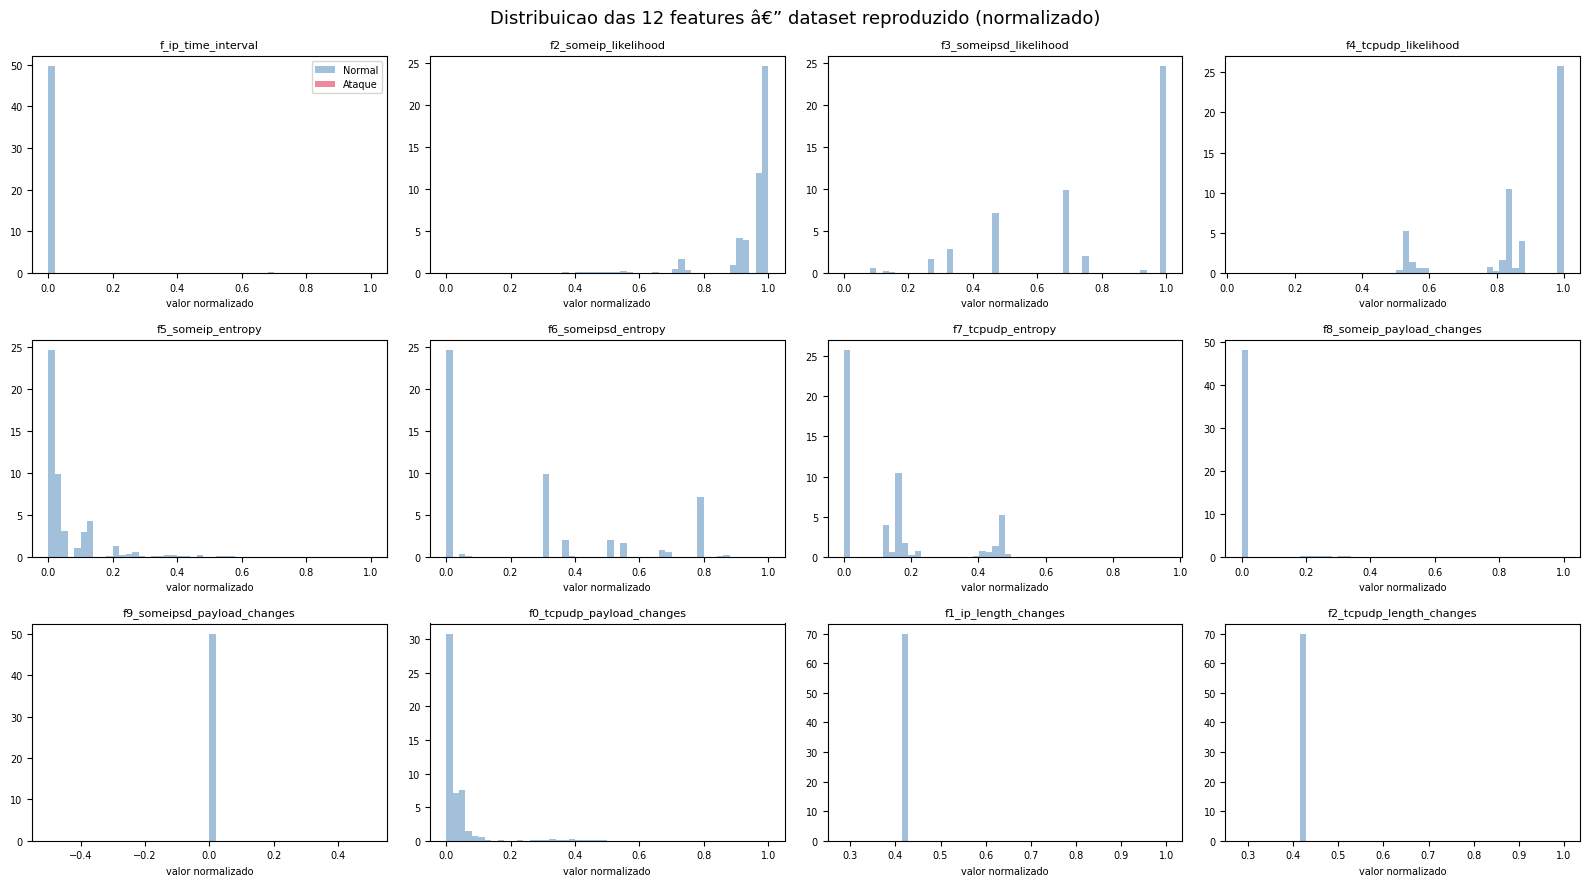

Salvo em feature_distributions.png


In [16]:
N_PLOT = min(50_000, len(y_train))
rng = np.random.default_rng(RANDOM_STATE)
idx_plot = rng.choice(len(y_train), size=N_PLOT, replace=False)
X_plot = X_train[idx_plot]
y_plot = y_train[idx_plot]

n_cols = 4
n_rows = (len(FEATURE_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
fig.suptitle('Distribuicao das 12 features â€” dataset reproduzido (normalizado)', fontsize=13)

for j, (col, ax) in enumerate(zip(FEATURE_COLS, axes.flat)):
    ax.hist(X_plot[y_plot == 0, j], bins=50, alpha=0.5, color='steelblue',
            density=True, label='Normal')
    ax.hist(X_plot[y_plot == 1, j], bins=50, alpha=0.5, color='crimson',
            density=True, label='Ataque')
    ax.set_title(col.replace('f0', 'f').replace('f1', 'f'), fontsize=8)
    ax.set_xlabel('valor normalizado', fontsize=7)
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.legend(fontsize=7)

for ax in axes.flat[len(FEATURE_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em feature_distributions.png')

## 10. Resumo final

Arquivos gerados e o que esperar de cada um.

In [17]:
print('=== Arquivos gerados ===')
for f in sorted(NPY_DIR.iterdir()):
    arr = np.load(f)
    print(f'  {f.name:<20}  shape={arr.shape}  dtype={arr.dtype}  '
          f'size={f.stat().st_size/1e6:.1f} MB')

print()
print('=== Expectativa de divergencia vs dataset Kim et al. ===')
print('  Valores exatos: DIFERENTES')
print('    Razao: modelo de bytes treinado com parametros nao publicados pelos autores.')
print('    As features de likelihood e entropy dependem da distribuicao de referencia')
print('    aprendida sobre o trafego benigno â€” variacoes nos parametros mudam os valores.')
print()
print('  Forma e separabilidade: SIMILAR')
print('    As classes normal e ataque devem ser discriminaveis no mesmo espaco.')
print('    Um XGBoost treinado neste dataset deve atingir metricas proximas ao artigo.')
print()
print('  Tamanho: PODE DIVERGIR')
print('    Se os PCAPs sao os mesmos do Figshare, o numero de amostras deve convergir.')
print('    Diferenca de contagem indica que o parser do artigo filtrou pacotes de forma diferente.')

=== Arquivos gerados ===
  X_test.npy            shape=(82762, 12)  dtype=float32  size=4.0 MB
  X_train.npy           shape=(82762, 12)  dtype=float32  size=4.0 MB
  y_test.npy            shape=(82762,)  dtype=int8  size=0.1 MB
  y_train.npy           shape=(82762,)  dtype=int8  size=0.1 MB

=== Expectativa de divergencia vs dataset Kim et al. ===
  Valores exatos: DIFERENTES
    Razao: modelo de bytes treinado com parametros nao publicados pelos autores.
    As features de likelihood e entropy dependem da distribuicao de referencia
    aprendida sobre o trafego benigno â€” variacoes nos parametros mudam os valores.

  Forma e separabilidade: SIMILAR
    As classes normal e ataque devem ser discriminaveis no mesmo espaco.
    Um XGBoost treinado neste dataset deve atingir metricas proximas ao artigo.

  Tamanho: PODE DIVERGIR
    Se os PCAPs sao os mesmos do Figshare, o numero de amostras deve convergir.
    Diferenca de contagem indica que o parser do artigo filtrou pacotes de forma 